In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [3]:
df = pd.read_csv(
    "parking_features.csv"
)

In [4]:
print("Shape:", df.shape)

df.head()

Shape: (35279, 30)


,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,...,Occupancy_Lag2,Occupancy_Lag3,RollingMean_3,RollingMean_6,RollingStd_6,OccupancyChange,OccupancyRate_Lag1,OccupancyRate_Lag2,TargetOccupancy,TimeDiff
0,BHMBCCMKT01,577,219,2016-10-04 10:59:48,0.379549,37.954939,358,2016-10-04,10,59,...,150.0,107.0,144.666667,106.500000,47.836179,27.0,0.306759,0.259965,247.0,0 days 00:32:59
1,BHMBCCMKT01,577,247,2016-10-04 11:25:47,0.428076,42.807626,330,2016-10-04,11,25,...,177.0,150.0,182.000000,132.833333,59.777644,42.0,0.379549,0.306759,259.0,0 days 00:25:59
2,BHMBCCMKT01,577,259,2016-10-04 11:59:44,0.448873,44.887348,318,2016-10-04,11,59,...,219.0,177.0,214.333333,163.333333,64.158138,28.0,0.428076,0.379549,266.0,0 days 00:33:57
3,BHMBCCMKT01,577,266,2016-10-04 12:29:45,0.461005,46.100520,311,2016-10-04,12,29,...,247.0,219.0,241.666667,193.166667,59.074247,12.0,0.448873,0.428076,269.0,0 days 00:30:01
4,BHMBCCMKT01,577,269,2016-10-04 13:02:48,0.466205,46.620451,308,2016-10-04,13,2,...,259.0,247.0,257.333333,219.666667,47.149408,7.0,0.461005,0.448873,263.0,0 days 00:33:03


In [5]:
model = joblib.load(
    "demand_model.pkl"
)

In [6]:
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


In [7]:
features = [
    "Capacity",
    "Occupancy",
    "OccupancyRate",
    "AvailableSpaces",

    "Hour",
    "Minute",
    "DayOfWeek",
    "IsWeekend",

    "HourSin",
    "HourCos",
    "DaySin",
    "DayCos",

    "Occupancy_Lag1",
    "Occupancy_Lag2",
    "Occupancy_Lag3",

    "RollingMean_3",
    "RollingMean_6",
    "RollingStd_6",

    "OccupancyChange",

    "OccupancyRate_Lag1",
    "OccupancyRate_Lag2"
]

In [8]:
missing_features = [
    col for col in features
    if col not in df.columns
]

print("Missing features:", missing_features)

Missing features: []


In [9]:
X = df[features].copy()

In [10]:
X = X.dropna()

In [11]:
print("X shape:", X.shape)

X shape: (35279, 21)


In [12]:
print(type(model))

<class 'xgboost.sklearn.XGBRegressor'>


In [13]:
model.feature_importances_

array([0.00891633, 0.496648  , 0.01517011, 0.00809443, 0.0294653 ,
       0.01213701, 0.00237372, 0.00295677, 0.01482368, 0.05776488,
       0.00498994, 0.00101309, 0.23961803, 0.04488751, 0.00130525,
       0.00335644, 0.00281598, 0.00883158, 0.02926895, 0.00336029,
       0.01220268], dtype=float32)

In [14]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

In [15]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [16]:
feature_importance

,Feature,Importance
1,Occupancy,0.496648
12,Occupancy_Lag1,0.239618
9,HourCos,0.057765
13,Occupancy_Lag2,0.044888
4,Hour,0.029465
18,OccupancyChange,0.029269
2,OccupancyRate,0.015170
8,HourSin,0.014824
20,OccupancyRate_Lag2,0.012203
5,Minute,0.012137


In [17]:
top_features = feature_importance.head(15)

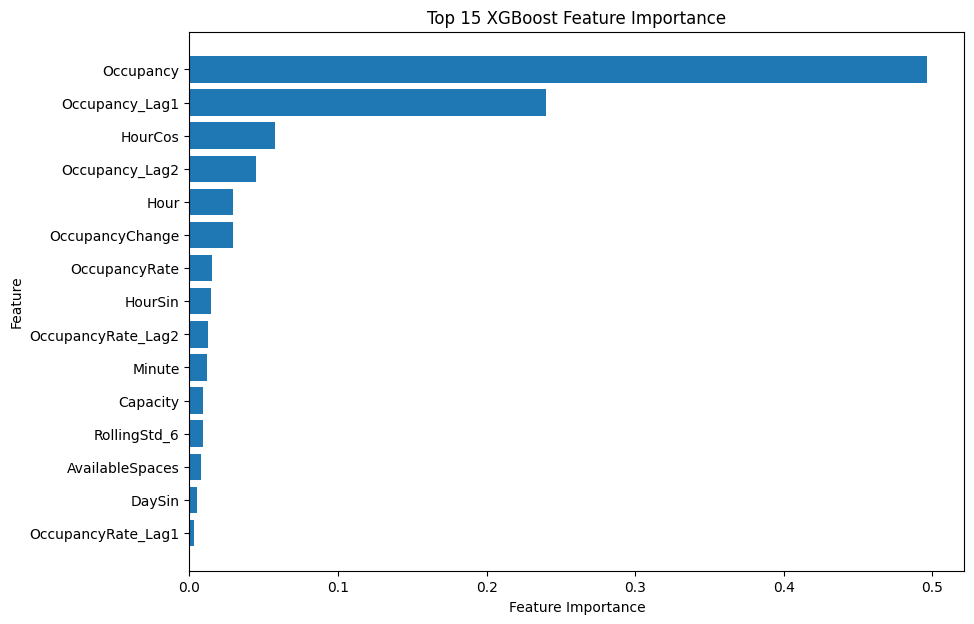

In [18]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importance")

plt.show()

Using SHAP

In [19]:
!pip install shap

In [20]:
import shap

In [21]:
explainer = shap.TreeExplainer(model)

In [22]:
X_sample = X.sample(
    min(2000, len(X)),
    random_state=42
)

In [24]:
shap_values = explainer(
    X_sample
)

shap_values

.values =
array([[-1.3184413e+00,  5.6021472e+02,  8.4098583e-01, ...,
        -3.2979481e+01, -1.5041399e-01, -8.5672992e-01],
       [-6.6231537e+00, -1.7503865e+02, -8.8756962e+00, ...,
        -2.4047821e+00,  6.6247067e+00,  6.0173774e+00],
       [-6.6245794e-01,  3.8537888e+02,  6.9207306e+00, ...,
        -5.0081028e+01,  2.9361906e+00, -2.7205092e-01],
       ...,
       [ 5.3720501e+01,  1.1631492e+03, -6.0783115e+01, ...,
         6.8243912e+01, -1.9062463e+00,  2.0789745e+00],
       [-1.1141168e+00,  5.0203461e+01,  6.8260317e+00, ...,
         1.0049258e+01,  1.7966816e+00, -2.0766993e+00],
       [ 1.5721941e+00, -1.3559464e+02, -1.0759932e+01, ...,
        -5.8558631e+00,  6.7469997e+00,  4.9547710e+00]], dtype=float32)

.base_values =
array([391.07343, 391.07343, 391.07343, ..., 391.07343, 391.07343,
       391.07343], dtype=float32)

.data =
array([[ 2.00900000e+03,  1.12400000e+03,  5.59482330e-01, ...,
        -3.40000000e+01,  5.84868094e-01,  6.01791936e-01],
    

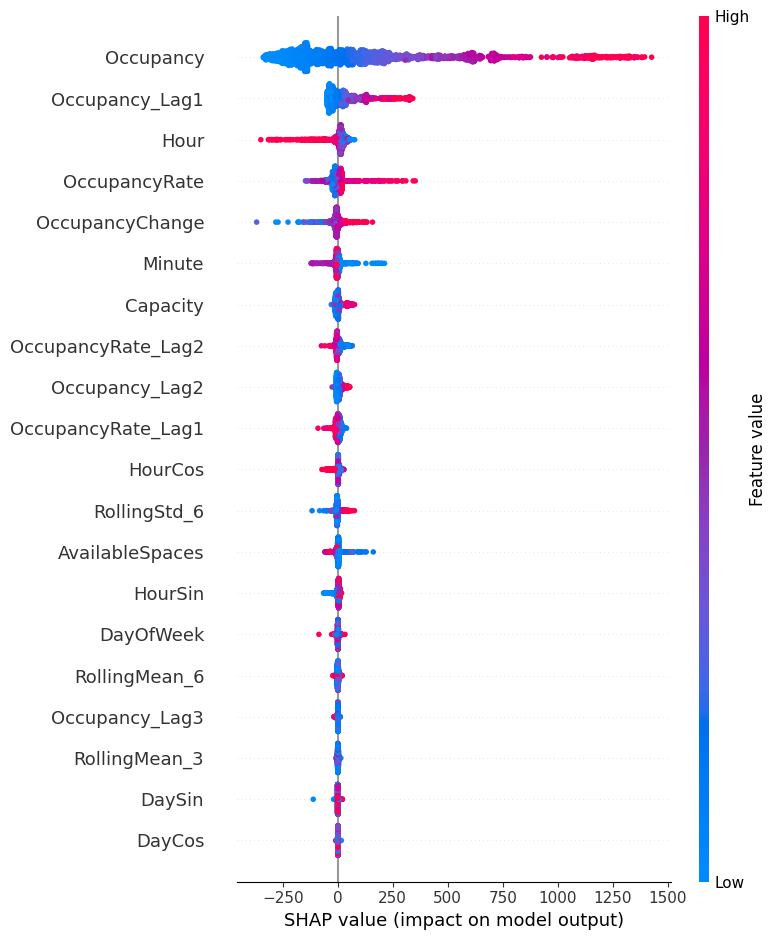

In [25]:
shap.summary_plot(
    shap_values,
    X_sample
)

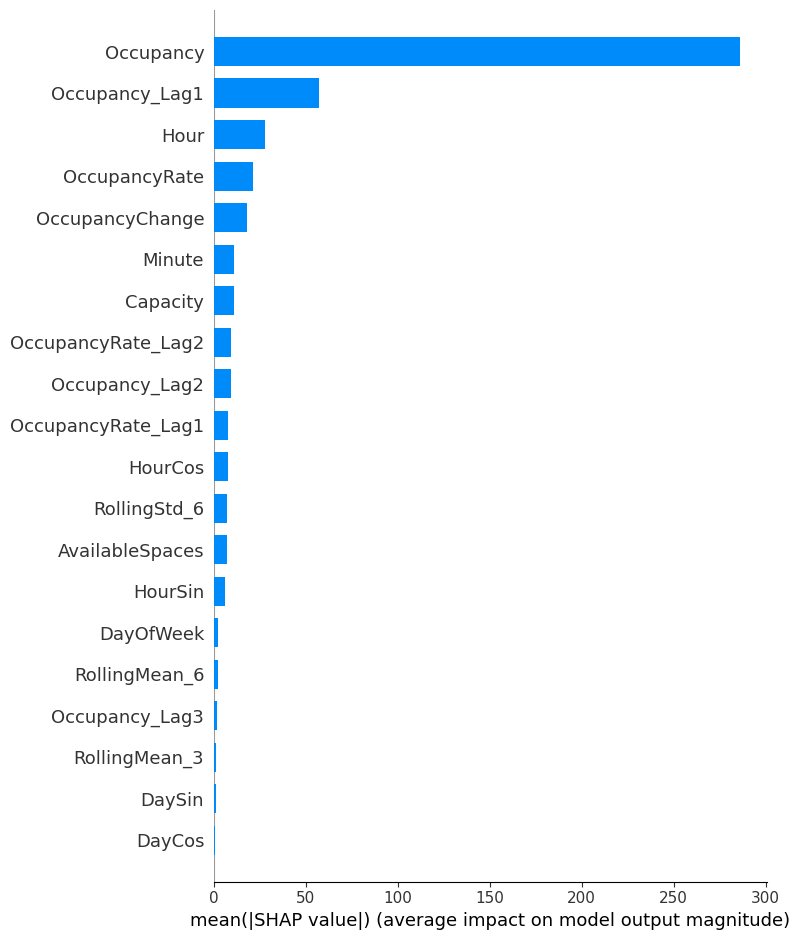

In [26]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

In [27]:
shap_importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "MeanAbsSHAP": np.abs(
        shap_values.values
    ).mean(axis=0)
})

In [28]:
shap_importance = shap_importance.sort_values(
    by="MeanAbsSHAP",
    ascending=False
)

In [29]:
shap_importance.head(10)

,Feature,MeanAbsSHAP
1,Occupancy,286.229675
12,Occupancy_Lag1,57.021339
4,Hour,27.529774
2,OccupancyRate,21.259480
18,OccupancyChange,17.855717
5,Minute,11.138090
0,Capacity,11.074866
20,OccupancyRate_Lag2,9.369610
13,Occupancy_Lag2,9.282563
19,OccupancyRate_Lag1,7.886310


In [30]:
importance_comparison = feature_importance.merge(
    shap_importance,
    on="Feature"
)

In [31]:
importance_comparison = (
    importance_comparison
    .sort_values(
        by="MeanAbsSHAP",
        ascending=False
    )
)

In [32]:
importance_comparison.head(15)

,Feature,Importance,MeanAbsSHAP
0,Occupancy,0.496648,286.229675
1,Occupancy_Lag1,0.239618,57.021339
4,Hour,0.029465,27.529774
6,OccupancyRate,0.015170,21.259480
5,OccupancyChange,0.029269,17.855717
9,Minute,0.012137,11.138090
10,Capacity,0.008916,11.074866
8,OccupancyRate_Lag2,0.012203,9.369610
3,Occupancy_Lag2,0.044888,9.282563
14,OccupancyRate_Lag1,0.003360,7.886310


In [33]:
row_index = 0

X_single = X_sample.iloc[[row_index]]

In [34]:
prediction = model.predict(
    X_single
)[0]

print(
    "Predicted Occupancy:",
    prediction
)

Predicted Occupancy: 1053.3824


In [35]:
single_shap = explainer(
    X_single
)

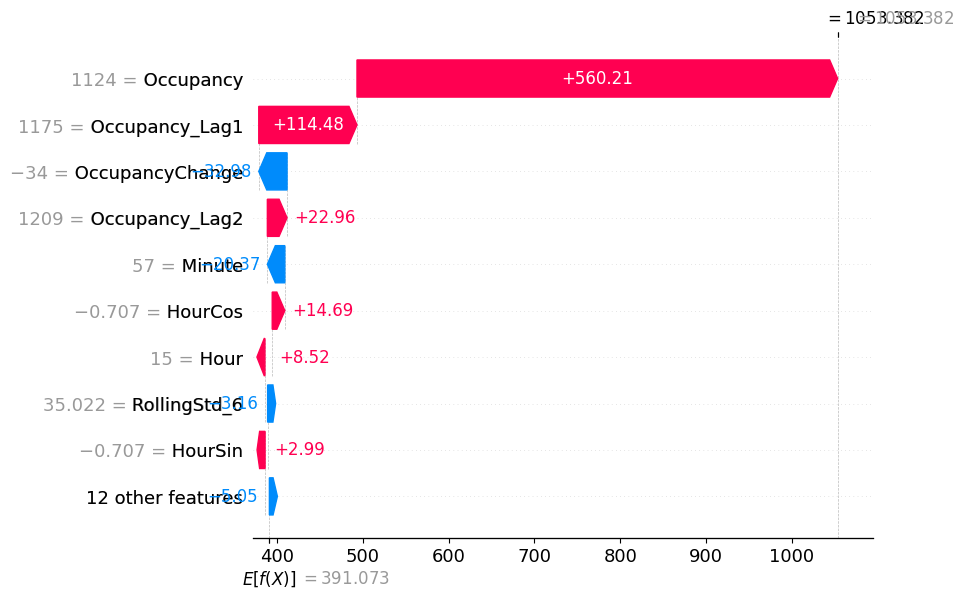

In [36]:
shap.plots.waterfall(
    single_shap[0]
)

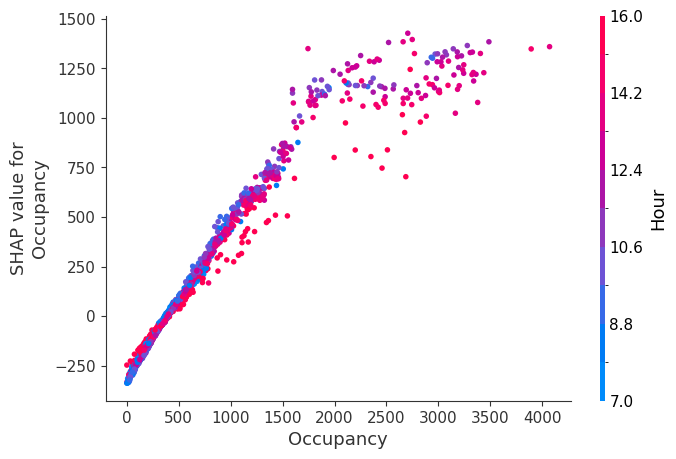

In [37]:
shap.dependence_plot(
    "Occupancy",
    shap_values.values,
    X_sample
)

In [38]:
shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)


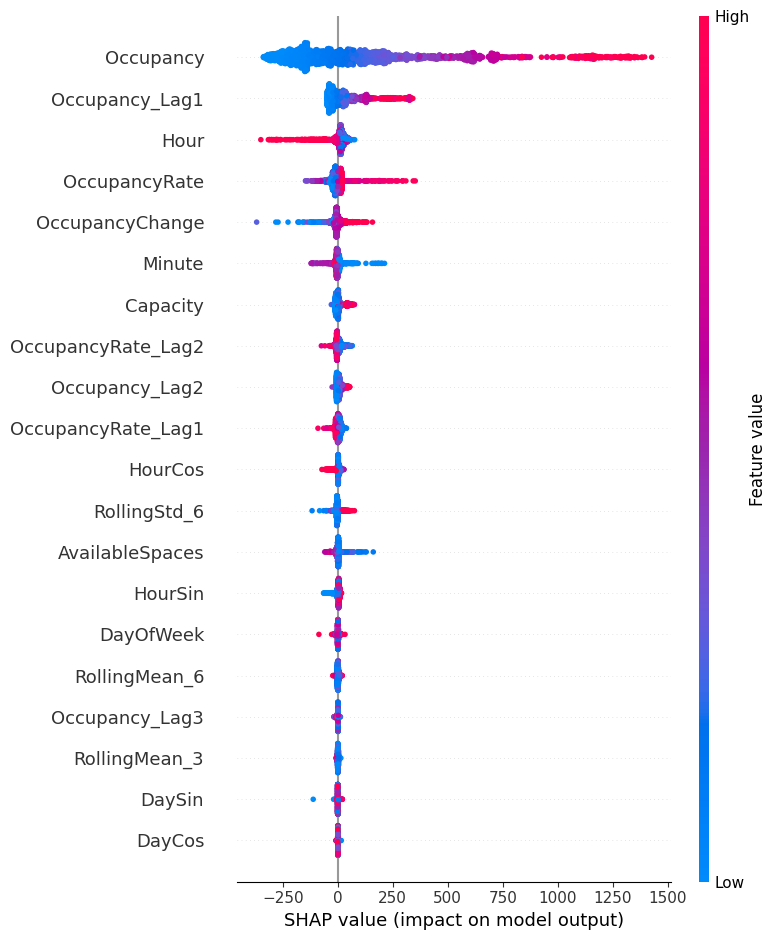

In [39]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.tight_layout()

plt.savefig(
    "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

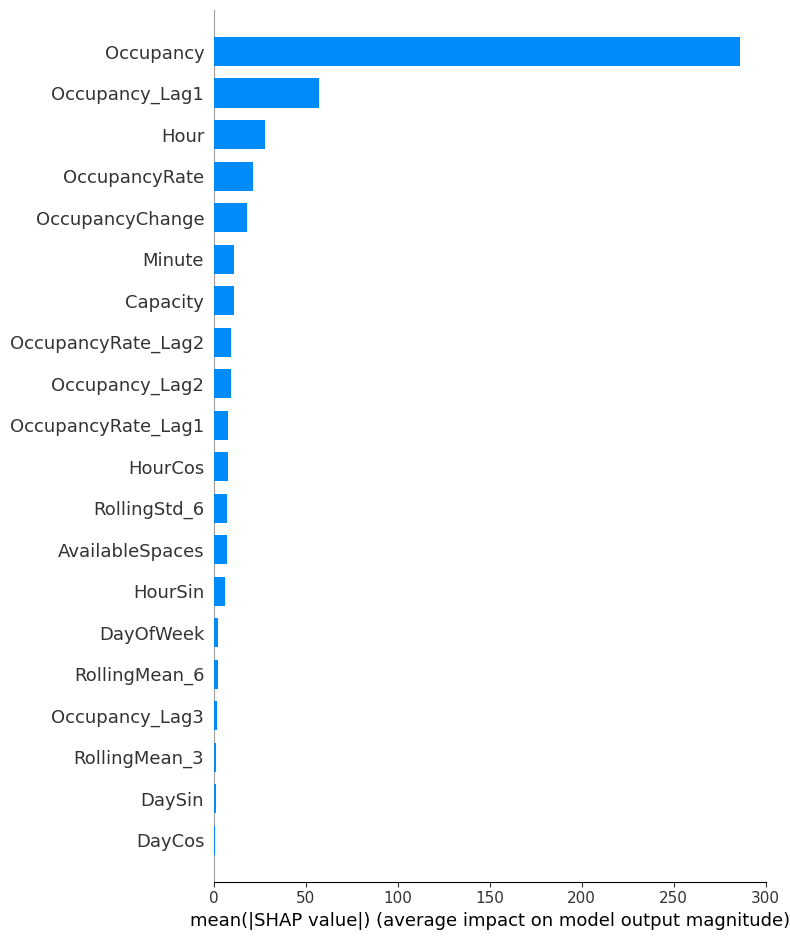

In [40]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()